# Statistics: estimation, sampling distributions, and inference
**DS-UA 201 · Fall 2026 · Week 3**  
**Center for Data Science, New York University**  
**TA: Xiang Gao**

[Open in Colab](https://colab.research.google.com/github/xgao0o/DS-UA_201-Causal-Inference-Fall-2026/blob/main/labs/3-Statistics.ipynb) (available after publication to the repository).

All data and numerical scenarios below are **synthetic teaching examples**, not empirical findings about NYU students or social media.


## Goals and roadmap
By the end of this lab, you should be able to distinguish a parameter, an estimator, and an estimate; explain bias, variance, and consistency; use the WLLN and CLT; and compute and interpret a two-sided test and confidence interval for a population mean.

| Core section |  |
|:--|--:|
| 1. Probability versus statistics
| 2. Estimators, bias, and variance
| 3. Consistency and the WLLN
| 4. Sampling distributions and the CLT
| 5. Hypothesis testing
| 6. Confidence intervals
| 7. Example: Instagram-followers


## Setup
Run cells from top to bottom with **Shift+Enter**, or choose **Restart Kernel and Run All Cells**. The notebook uses NumPy, pandas, Matplotlib, and SciPy; it downloads no data. Each simulation has a fixed random seed.

If needed, install dependencies in your environment with `python -m pip install numpy pandas matplotlib scipy` (in Colab, use `%pip install numpy pandas matplotlib scipy`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## 1. Probability versus statistics
Suppose $X_1,\ldots,X_n$ are **independent and identically distributed (i.i.d.)** draws from a distribution with CDF $F$.

- **Probability:** given $F$, describe what samples might look like; for example, compute $P(a\leq\bar X_n\leq b)$.
- **Statistics:** given observations $x_1,\ldots,x_n$, learn about an unknown feature of $F$, such as its mean $\mu=\mathbb E[X]$.

| Object | Meaning | Example |
|:--|:--|:--|
| Parameter | Fixed feature of the population distribution | $\mu=\mathbb E[X]$ |
| Estimator | Rule applied to random data; itself a random variable | $\bar X_n=n^{-1}\sum_{i=1}^n X_i$ |
| Estimate | Number obtained from the observed data | $\bar x_n=n^{-1}\sum_{i=1}^n x_i$ |

A **sampling distribution** is the distribution of an estimator across repeated samples of the same size. It differs from the distribution of individual observations.

In a simulation we choose the true parameter, so we can check our methods. An analyst with real data usually does not know it.


## 2. Estimators, bias, and variance
### Estimating a Gaussian mean
We write $X\sim N(\mu,\sigma^2)$: the second parameter is the **variance**. Its density is

$$f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right),\qquad \sigma>0.$$

Take $\mu=5$, $\sigma=2$, and $n=1{,}000$. NumPy's `normal` function takes the **standard deviation** as `scale`.


In [2]:
mean_rng = np.random.default_rng(42)
true_mu, true_sigma = 5.0, 2.0
n_mean = 1_000
observations = mean_rng.normal(loc=true_mu, scale=true_sigma, size=n_mean)
mean_estimate = observations.mean()

print(f"Known simulation parameter mu: {true_mu:.3f}")
print(f"Realized sample mean:          {mean_estimate:.3f}")
print(f"Realized estimation error:     {mean_estimate - true_mu:.3f}")


Known simulation parameter mu: 5.000
Realized sample mean:          4.942
Realized estimation error:     -0.058


### Bias and variance are repeated-sampling properties
For an estimator $\hat\theta$ of $\theta$,

$$\operatorname{Bias}(\hat\theta)=\mathbb E[\hat\theta]-\theta,
\qquad \operatorname{Var}(\hat\theta)=\mathbb E[(\hat\theta-\mathbb E[\hat\theta])^2].$$

The expectation is over repeated samples. A realized estimation error $\hat\theta-\theta$ is not the estimator's bias.

For i.i.d. observations with finite mean $\mu$ and variance $\sigma^2$,

$$\mathbb E[\bar X_n]=\frac1n\sum_i\mathbb E[X_i]=\mu,$$

$$\operatorname{Var}(\bar X_n)=\frac1{n^2}\sum_i\operatorname{Var}(X_i)=\frac{\sigma^2}{n}.$$

Independence makes the covariance terms zero. These two results do **not** require Gaussian observations.

A **standard error (SE)** is the standard deviation of an estimator's sampling distribution. Here it is $\sigma/\sqrt n$. When $\sigma$ is unknown, estimate it by $s/\sqrt n$, where

$$s^2=\frac{1}{n-1}\sum_{i=1}^n(x_i-\bar x_n)^2.$$

Use `ddof=1` to compute $s^2$ or $s$. The observations' standard deviation $s$ and the mean's estimated standard error $s/\sqrt n$ measure different kinds of variation.


In [5]:
# Each row is a new independent sample; each row mean is a new estimate.
repetition_rng = np.random.default_rng(201)
repetitions = 5_000
repeated_samples = repetition_rng.normal(
    true_mu, true_sigma, size=(repetitions, n_mean)
)
repeated_means = repeated_samples.mean(axis=1)

sampling_summary = pd.DataFrame({
    "Quantity": ["Mean of estimator", "Bias", "Variance", "Standard error"],
    "Theoretical": [true_mu, 0, true_sigma**2 / n_mean,
                    true_sigma / np.sqrt(n_mean)],
    "Monte Carlo approximation": [
        repeated_means.mean(), repeated_means.mean() - true_mu,
        repeated_means.var(ddof=1), repeated_means.std(ddof=1),
    ],
}).set_index("Quantity")
display(sampling_summary.round(5))
print(f"Estimated SE from the single sample: "
      f"{observations.std(ddof=1) / np.sqrt(n_mean):.5f}")
del repeated_samples  # Keep only the estimates needed below.


,Theoretical,Monte Carlo approximation
Quantity,,
Mean of estimator,5.00000,4.99902
Bias,0.00000,-0.00098
Variance,0.00400,0.00405
Standard error,0.06325,0.06364


Estimated SE from the single sample: 0.06256


The simulation approximates expectations with averages over 5,000 repetitions. Its nonzero estimated bias is Monte Carlo noise; the mathematical bias of $\bar X_n$ is exactly zero here.

### Exercise 1
1. If we multiply the sample size by four, what happens to the variance and standard error of the sample mean?
2. Is $X_1$, the first observation alone, also an unbiased estimator of $\mu$? Is it as precise as $\bar X_n$?

<details><summary>Answer</summary>

1. The variance becomes one quarter as large; the standard error becomes one half as large.
2. Yes: $\mathbb E[X_1]=\mu$. But $\operatorname{Var}(X_1)=\sigma^2$, compared with $\sigma^2/n$ for the mean. Unbiasedness alone does not guarantee a precise estimator.

</details>


## 3. Consistency and the WLLN
An estimator $\hat\theta_n$ is **consistent** for $\theta$ if, for every $\epsilon>0$,

$$P(|\hat\theta_n-\theta|>\epsilon)\longrightarrow0\quad\text{as }n\longrightarrow\infty.$$

The **weak law of large numbers (WLLN)** gives this result for the sample mean of i.i.d. observations with a finite absolute first moment. Under our stronger finite-variance assumption, Chebyshev's inequality gives a short proof:

$$P(|\bar X_n-\mu|>\epsilon)\leq\frac{\operatorname{Var}(\bar X_n)}{\epsilon^2}
=\frac{\sigma^2}{n\epsilon^2}\longrightarrow0.$$

Consistency concerns probabilities across repeated samples. It does not say that every increase in sample size improves a particular estimate.


,Simulated P(|mean - mu| > 0.25),Exact Gaussian probability,Chebyshev bound (capped at 1)
n,,,
10,0.6900,0.6926,1.000
50,0.3680,0.3768,1.000
100,0.2050,0.2113,0.640
500,0.0048,0.0052,0.128
1000,0.0000,0.0001,0.064


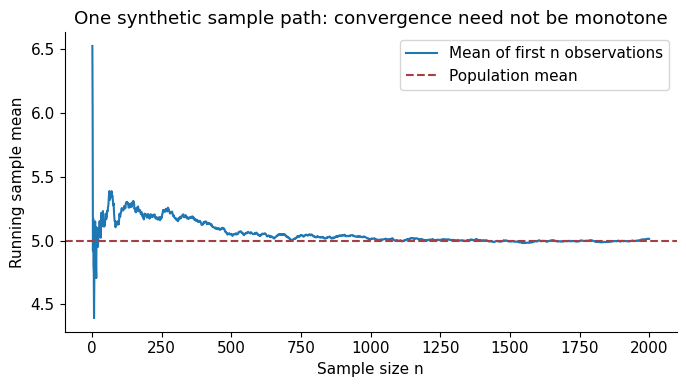

In [6]:
consistency_rng = np.random.default_rng(2026)
sample_sizes = [10, 50, 100, 500, 1_000]
epsilon = 0.25
consistency_rows = []
for sample_size in sample_sizes:
    draws = consistency_rng.normal(
        true_mu, true_sigma, size=(repetitions, sample_size)
    )
    means = draws.mean(axis=1)
    consistency_rows.append({
        "n": sample_size,
        "Simulated P(|mean - mu| > 0.25)": np.mean(np.abs(means - true_mu) > epsilon),
        "Exact Gaussian probability": 2 * stats.norm.sf(
            epsilon / (true_sigma / np.sqrt(sample_size))
        ),
        "Chebyshev bound (capped at 1)": min(
            1, true_sigma**2 / (sample_size * epsilon**2)
        ),
    })
consistency_table = pd.DataFrame(consistency_rows).set_index("n")
display(consistency_table.round(4))

# A single growing sample can move both toward and away from the truth.
path = consistency_rng.normal(true_mu, true_sigma, size=2_000)
indices = np.arange(1, len(path) + 1)
running_mean = np.cumsum(path) / indices
fig, ax = plt.subplots()
ax.plot(indices, running_mean, label="Mean of first n observations")
ax.axhline(true_mu, color="#a33f45", linestyle="--", label="Population mean")
ax.set(xlabel="Sample size n", ylabel="Running sample mean",
       title="One synthetic sample path: convergence need not be monotone")
ax.legend()
fig.tight_layout()
plt.show()
del draws


### Exercise 2: unbiased versus consistent
For the nondegenerate Gaussian population above, compare $X_1$ and $\bar X_n+1/n$ as estimators of $\mu$. Which are unbiased? Which are consistent?

<details><summary>Answer</summary>

$X_1$ is unbiased, but is not consistent: increasing $n$ leaves its distribution unchanged, so the probability of an error larger than a fixed $\epsilon$ does not approach zero.

$\bar X_n+1/n$ has bias $1/n$ at every finite $n$, but is consistent because $\bar X_n$ converges in probability to $\mu$ and $1/n\to0$. Thus unbiasedness and consistency are different properties.

</details>


## 4. Sampling distributions and the CLT
### Gaussian data: exact normality
If $X_i\overset{\mathrm{i.i.d.}}\sim N(\mu,\sigma^2)$, then for **every** $n$,

$$\bar X_n\sim N\!\left(\mu,\frac{\sigma^2}{n}\right).$$

The next plot compares individual observations with means of 1,000 observations. The means are much less variable.


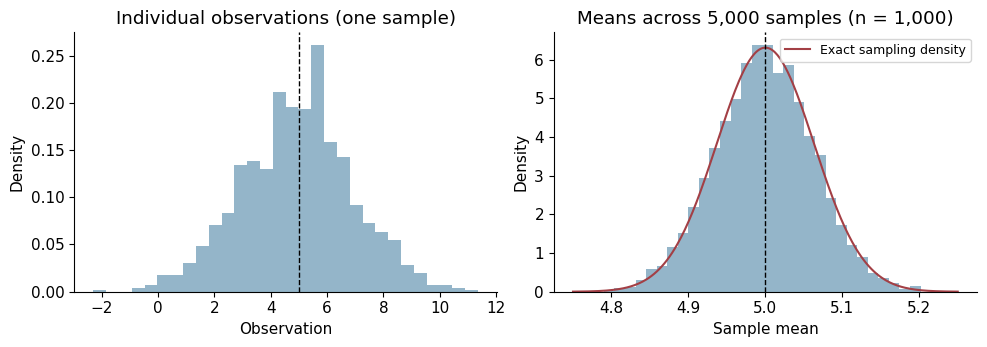

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].hist(observations, bins=30, density=True, color="#6796b3", alpha=0.7)
axes[0].set(title="Individual observations (one sample)", xlabel="Observation")
axes[1].hist(repeated_means, bins=30, density=True, color="#6796b3", alpha=0.7)
mean_grid = np.linspace(true_mu - 0.25, true_mu + 0.25, 300)
axes[1].plot(mean_grid, stats.norm.pdf(mean_grid, true_mu, true_sigma / np.sqrt(n_mean)),
             color="#a33f45", label="Exact sampling density")
axes[1].set(title="Means across 5,000 samples (n = 1,000)", xlabel="Sample mean")
axes[1].legend(fontsize=9)
for ax in axes:
    ax.axvline(true_mu, color="black", linestyle="--", linewidth=1)
    ax.set_ylabel("Density")
fig.tight_layout()
plt.show()


### Non-Gaussian data: asymptotic normality
For i.i.d. observations with mean $\mu$ and variance $0<\sigma^2<\infty$, the **central limit theorem (CLT)** states

$$\frac{\sqrt n(\bar X_n-\mu)}{\sigma}\xrightarrow{d}N(0,1).$$

Thus, for sufficiently large $n$, the sampling distribution of $\bar X_n$ is approximately $N(\mu,\sigma^2/n)$. The CLT describes the distribution of the **standardized estimation error**; it does not make the individual observations normal. There is no universal sample-size cutoff at which the approximation is good.

$X_i\sim\operatorname{Bernoulli}(p)$ with $p=0.7$, so $\mu=p$ and $\sigma^2=p(1-p)$. Plot standardized means on a common scale to separate the shape change from the shrinking variance.


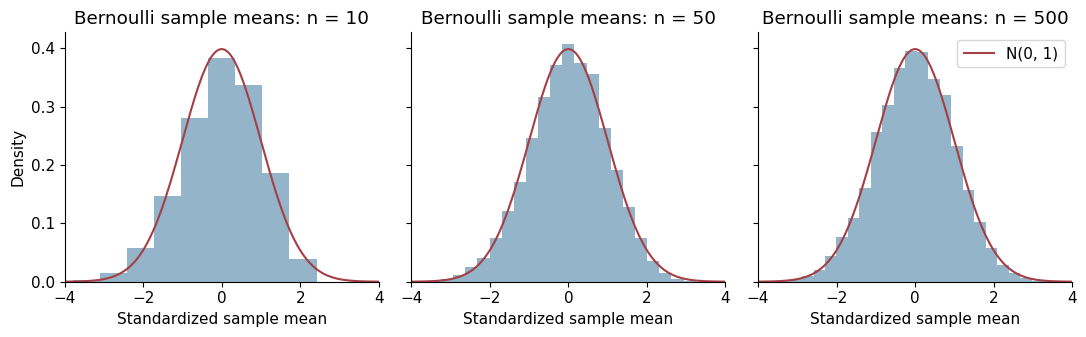

In [8]:
clt_rng = np.random.default_rng(703)
bernoulli_p = 0.7
z_grid = np.linspace(-4, 4, 400)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharex=True, sharey=True)
for ax, sample_size in zip(axes, [10, 50, 500]):
    # The sum of n independent Bernoulli(p) draws is Binomial(n, p).
    counts = clt_rng.binomial(sample_size, bernoulli_p, size=10_000)
    proportions = counts / sample_size
    standardized = ((proportions - bernoulli_p)
                    / np.sqrt(bernoulli_p * (1 - bernoulli_p) / sample_size))
    # Align bins with the discrete support; merge adjacent values for large n.
    spacing = 1 / np.sqrt(sample_size * bernoulli_p * (1 - bernoulli_p))
    bin_width = spacing * max(1, int(round(0.3 / spacing)))
    bins = np.arange(standardized.min() - spacing / 2,
                     standardized.max() + bin_width, bin_width)
    ax.hist(standardized, bins=bins, density=True, color="#6796b3", alpha=0.7)
    ax.plot(z_grid, stats.norm.pdf(z_grid), color="#a33f45", label="N(0, 1)")
    ax.set(title=f"Bernoulli sample means: n = {sample_size}",
           xlabel="Standardized sample mean", xlim=(-4, 4))
axes[0].set_ylabel("Density")
axes[-1].legend()
fig.tight_layout()
plt.show()


### Exercise 3
Match each claim to the WLLN or CLT: (a) a sample proportion is likely to be close to $p$ for large $n$; (b) its standardized error has an approximately standard normal distribution. Is the sample proportion exactly normal at finite $n$?

<details><summary>Answer</summary>

(a) WLLN; (b) CLT. The sample proportion is discrete at finite $n$, so it is not exactly normal. The approximation improves as the expected numbers of successes and failures grow. Even when the approximation is good, each individual observation remains 0 or 1.

</details>


## 5. Hypothesis testing
A test assesses how compatible the data are with a specified **null hypothesis**, using a sampling model.

Generate 1,000 observations from $N(5,1.5^2)$ and test

$$H_0:\mu=8\qquad\text{versus}\qquad H_1:\mu\ne8.$$

Set the significance level $\alpha=0.05$ before examining the result. A **Type I error** is rejecting $H_0$ when it is true. A level-$\alpha$ test controls that probability at no more than $\alpha$ under its assumptions; this is not the probability that a particular conclusion is wrong.

We reject or **fail to reject** $H_0$. Failing to reject does not prove the null; rejecting does not prove a particular alternative value.


In [9]:
test_rng = np.random.default_rng(42)
test_data = test_rng.normal(loc=5.0, scale=1.5, size=1_000)
mu_0 = 8.0
alpha = 0.05
n_test = len(test_data)
xbar = test_data.mean()
s = test_data.std(ddof=1)
se = s / np.sqrt(n_test)

display(pd.Series({"n": n_test, "Sample mean": xbar,
                   "Sample standard deviation": s, "Estimated standard error": se})
        .to_frame("Observed value").round(4))


,Observed value
n,1000.0000
Sample mean,4.9567
Sample standard deviation,1.4838
Estimated standard error,0.0469


### A signed statistic, then a two-sided rejection rule
With unknown population standard deviation, use

$$T=\frac{\bar X_n-\mu_0}{S/\sqrt n}.$$

Under $H_0$ and i.i.d. Gaussian sampling, the **signed** statistic has a Student $t$ distribution with $n-1$ degrees of freedom.

Let $F_{t_{n-1}}$ be the $t$ CDF. For a two-sided test,

$$c_t=F_{t_{n-1}}^{-1}(1-\alpha/2),\qquad
\text{reject when }|T|>c_t,$$

$$p\text{-value}=P_{H_0}(|T|\geq|t_{\mathrm{obs}}|)
=2\left[1-F_{t_{n-1}}(|t_{\mathrm{obs}}|)\right].$$

This is the probability, **under the null and the sampling assumptions**, of a statistic at least as extreme as observed. It is not $P(H_0\mid\text{data})$.

Use SciPy's survival function `sf` for upper-tail probabilities; it avoids the numerical cancellation that can occur in `1 - cdf`.


In [ ]:
t_observed = (xbar - mu_0) / se
degrees_freedom = n_test - 1
t_critical = stats.t.ppf(1 - alpha / 2, df=degrees_freedom)
p_value = 2 * stats.t.sf(abs(t_observed), df=degrees_freedom)

print(f"Signed t statistic: {t_observed:.4f}")
print(f"Two-sided critical values: +/- {t_critical:.4f}")
if p_value == 0:
    print("Two-sided p-value: below numerical range (SciPy returned 0.0)")
else:
    print(f"Two-sided p-value: {p_value:.3e}")
print("Decision:", "Reject H0" if p_value < alpha else "Fail to reject H0")

# Check the hand calculation against SciPy's one-sample t-test.
scipy_result = stats.ttest_1samp(test_data, popmean=mu_0)
assert np.isclose(t_observed, scipy_result.statistic)
assert np.isclose(p_value, scipy_result.pvalue, rtol=1e-10, atol=0)
assert (abs(t_observed) > t_critical) == (p_value < alpha)

# Also check a representable p-value; agreement at numerical zero is insufficient.
t_at_five = (xbar - 5.0) / se
p_at_five = 2 * stats.t.sf(abs(t_at_five), df=degrees_freedom)
assert np.isclose(p_at_five, stats.ttest_1samp(test_data, popmean=5.0).pvalue)
print(f"For comparison, testing mu = 5 gives p = {p_at_five:.4f} "
      "(fail to reject at 5%).")


Signed t statistic: -64.8585
Two-sided critical values: +/- 1.9623
Two-sided p-value: below numerical range (SciPy returned 0.0)
Decision: Reject H0
For comparison, testing mu = 5 gives p = 0.3559 (fail to reject at 5%).


The result is strong evidence against $\mu=8$ under this model. It does not establish that $\mu$ is exactly 5. For the very distant null value 8, even the survival function underflows to zero in floating-point arithmetic. The mathematical p-value is positive; the output therefore labels this numerical limit rather than reporting an exact zero. For the comparison null value 5, the p-value is representable and we fail to reject; that still does not prove the mean is 5.

### Connection to the normal approximation in the source notebooks
For large $n$, substituting a consistent estimate of $\sigma$ into the CLT gives an approximately standard normal signed statistic under $H_0$. The corresponding formulas use

$$c_z=\Phi^{-1}(1-\alpha/2),\qquad
p_z\approx2[1-\Phi(|t_{\mathrm{obs}}|)].$$

Here $\Phi$ is the standard normal CDF. If $\sigma$ were known and the data Gaussian, the statistic using $\sigma$ would be exactly standard normal. With unknown $\sigma$ and Gaussian data, the $t$ reference used above is exact. For non-Gaussian i.i.d. data with finite nonzero variance, studentized normal inference is asymptotic, not an exact small-sample result.


Normal critical value: 1.9600
t critical value (df=999): 1.9623


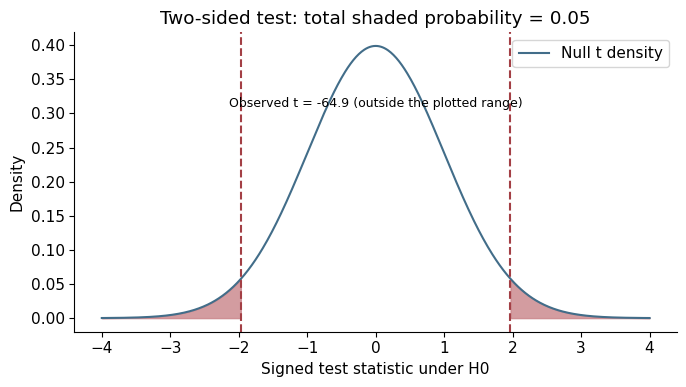

In [ ]:
z_critical = stats.norm.ppf(1 - alpha / 2)
print(f"Normal critical value: {z_critical:.4f}")
print(f"t critical value (df={degrees_freedom}): {t_critical:.4f}")

# Visualize the null reference distribution and its two rejection tails.
reference_grid = np.linspace(-4, 4, 600)
null_density = stats.t.pdf(reference_grid, df=degrees_freedom)
fig, ax = plt.subplots()
ax.plot(reference_grid, null_density, color="#426d89", label="Null t density")
for tail in [reference_grid <= -t_critical, reference_grid >= t_critical]:
    ax.fill_between(reference_grid, 0, null_density, where=tail,
                    color="#c98389", alpha=0.8)
ax.axvline(-t_critical, color="#a33f45", linestyle="--")
ax.axvline(t_critical, color="#a33f45", linestyle="--")
ax.set(title="Two-sided test: total shaded probability = 0.05",
       xlabel="Signed test statistic under H0", ylabel="Density")
ax.text(0.5, 0.75, f"Observed t = {t_observed:.1f} (outside the plotted range)",
        transform=ax.transAxes, ha="center", fontsize=9)
ax.legend()
fig.tight_layout()
plt.show()


### Exercise 4
Suppose another dataset gives a two-sided p-value of 0.08. At $\alpha=0.05$, what is the decision? Does the p-value mean that the null has an 8% chance of being true?

<details><summary>Answer</summary>

Fail to reject $H_0$. Under the null and the sampling model, a statistic at least as extreme as observed has probability 0.08. This is not a probability assigned to the null hypothesis. The data may be too imprecise to distinguish the null from scientifically meaningful alternatives.

</details>


## 6. Confidence intervals
Under the same i.i.d. Gaussian model with unknown $\sigma$, a $100(1-\alpha)\%$ confidence interval for $\mu$ is

$$C(X_1,\ldots,X_n)=\left[\bar X_n-c_t\frac{S}{\sqrt n},\
\bar X_n+c_t\frac{S}{\sqrt n}\right].$$

Before sampling, the endpoints are random and the parameter is fixed. Over repeated samples, a 95% procedure covers the true $\mu$ in 95% of samples under the model. After observing the data, this particular interval either contains $\mu$ or does not; the frequentist coverage statement does not assign a 95% probability to the fixed parameter lying in the realized interval.

Replacing $c_t$ by $c_z$ gives the corresponding large-sample normal interval. The margin of error is a multiple of the **standard error**, not of the standard deviation of individual observations.


95% t confidence interval for mu: [4.8646, 5.0487]
Null value 8 inside interval: False


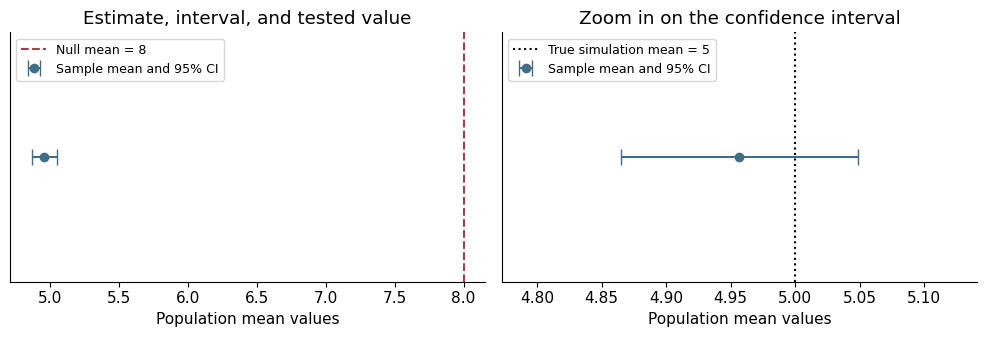

In [ ]:
margin = t_critical * se
ci_low, ci_high = xbar - margin, xbar + margin
print(f"95% t confidence interval for mu: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Null value {mu_0:g} inside interval: {ci_low <= mu_0 <= ci_high}")
assert (p_value < alpha) == (mu_0 < ci_low or mu_0 > ci_high)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax in axes:
    ax.errorbar(xbar, 0, xerr=margin, fmt="o", capsize=6,
                color="#426d89", label="Sample mean and 95% CI")
    ax.set(yticks=[], xlabel="Population mean values")
axes[0].axvline(mu_0, color="#a33f45", linestyle="--", label="Null mean = 8")
axes[0].set_title("Estimate, interval, and tested value")
axes[0].legend(fontsize=9)
axes[1].axvline(5.0, color="black", linestyle=":", label="True simulation mean = 5")
axes[1].set_title("Zoom in on the confidence interval")
axes[1].set_xlim(ci_low - margin, ci_high + margin)
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()


### Exercise 5: testing and intervals agree
1. Why is 8 outside the interval?
2. Is this interval intended to contain 95% of individual observations?
3. If we demand 99% confidence from the same data, does the interval widen or narrow?

<details><summary>Answer</summary>

1. Inverting the same two-sided test gives the confidence interval: the 95% interval consists of null means that would not be rejected at $\alpha=0.05$. The tested value 8 is rejected.
2. No. It quantifies uncertainty about the population mean. Individual observations vary much more than sample means.
3. It widens because the critical value increases; achieving more coverage requires a larger margin of error.

</details>


## 7. Example: Instagram-followers
Return to the 2025 question: what is the mean number of Instagram followers among all NYU students? Specify how students without accounts are recorded; for this teaching scenario, count them as zero. The target is a **descriptive population mean**, not a causal effect.

Suppose a hypothetical random sample of $n=100$ students gives $\bar x=250$ followers and **estimated standard error 50 followers**. These are stipulated sample summaries, not measurements or a newly simulated dataset. Then

$$\widehat{\operatorname{Var}}(\bar X_n)=50^2=2{,}500,
\qquad s=50\sqrt{100}=500.$$

The standard deviation of individual follower counts is 500, not 50. Test $H_0:\mu=150$ against $H_1:\mu\ne150$ using the large-sample normal approximation from the source recap.


In [ ]:
followers_n = 100
followers_mean = 250.0
followers_se = 50.0
followers_s = followers_se * np.sqrt(followers_n)
followers_null = 150.0
followers_z = (followers_mean - followers_null) / followers_se
followers_p = 2 * stats.norm.sf(abs(followers_z))
followers_ci = (
    followers_mean - z_critical * followers_se,
    followers_mean + z_critical * followers_se,
)

print(f"Implied sample standard deviation: {followers_s:.0f} followers")
print(f"Signed standardized statistic: {followers_z:.2f}")
print(f"Approximate two-sided p-value: {followers_p:.4f}")
print(f"Approximate 95% CI: [{followers_ci[0]:.1f}, {followers_ci[1]:.1f}]")
print("Decision:", "Reject H0" if followers_p < alpha else "Fail to reject H0")
assert np.isclose(followers_z, 2.0)


Implied sample standard deviation: 500 followers
Signed standardized statistic: 2.00
Approximate two-sided p-value: 0.0455
Approximate 95% CI: [152.0, 348.0]
Decision: Reject H0


This example is just below the 5% rejection threshold under the approximation. It is not strong evidence of a large practical difference by itself, and the p-value is not the probability that $\mu=150$ is true. Follower counts can be highly skewed: $n=100$ alone does not guarantee accurate normal inference. Raw data and the sampling design would be needed to assess that approximation.

### Closing exercise
Would interviewing only your own Instagram followers necessarily give a representative sample of NYU students? Would collecting many more responses from that same group fix the problem?

<details><summary>Answer</summary>

No. Inclusion may be related to social networks and follower counts, so this is a convenience sample. More observations can reduce sampling variability around the wrong target while leaving selection bias. Consistency for the intended population mean depends on how the data were sampled, not only on sample size.

</details>

### Connection to causal inference
Keep four steps distinct: a **causal parameter** such as $\mathbb E[Y(1)-Y(0)]$; **identification assumptions** connecting it to observed data; an **estimator**; and the **realized estimate** and its sampling uncertainty. A small standard error or p-value does not establish identification or eliminate confounding. This lab develops statistical tools; causal study designs come later.
